# Project # 30 - Movie Chatbot - Intent detection using NLP techniques

# Intent Classification Model Training

This notebook implements a complete training pipeline for an intent classification model using a Bag-of-Words approach and a neural network. The model learns to classify user intents from input patterns defined in a JSON file.

This notebook is structured into several sections, each focusing on a key aspect of building an intent classification model for a movie chatbot. The goal is to classify user queries into predefined intents (e.g., 'movie_action', 'movie_comedy') to enable relevant movie recommendations. The model utilizes a Bag-of-Words approach combined with a simple neural network.

## Section 1: Import Required Libraries

Import all necessary libraries for data processing, model training, and utilities.

This section is dedicated to importing all the necessary Python libraries that will be used throughout the notebook for tasks such as data manipulation, natural language processing, neural network creation, and data visualization. Key libraries include `nltk` for text processing, `torch` for building and training the neural network, `numpy` for numerical operations, `matplotlib` and `seaborn` for plotting, and `sklearn` for model evaluation metrics like the confusion matrix.

In [36]:
pip install matplotlib seaborn nltk torch

This cell ensures that all required Python packages for this project are installed. `matplotlib` and `seaborn` are used for plotting, `nltk` for natural language processing tasks such as tokenization and stemming, and `torch` for building and training the neural network model. The `pip install` command checks for and installs these packages if they are not already present in the environment.

In [37]:
import numpy as np
import nltk
from nltk.stem.porter import PorterStemmer

stemmer = PorterStemmer()

def tokenize(sentence):
    return nltk.word_tokenize(sentence)

def stem(word):
    return stemmer.stem(word.lower())

def bag_of_words(tokenized_sentence, words):
    sentence_words = [stem(w) for w in tokenized_sentence]
    bag = np.zeros(len(words), dtype=np.float32)
    for idx, w in enumerate(words):
        if w in sentence_words:
            bag[idx] = 1
    return bag

This cell defines essential utility functions for natural language processing (NLP).
*   `tokenize(sentence)`: Splits a given sentence into individual words or tokens.
*   `stem(word)`: Reduces words to their root form (e.g., 'running' -> 'run') using NLTK's Porter Stemmer, which helps in reducing the vocabulary size and treating morphologically similar words as the same.
*   `bag_of_words(tokenized_sentence, words)`: Creates a Bag-of-Words representation for a given tokenized sentence. This function generates a vector where each element corresponds to a word in the vocabulary, with a value of 1 if the word is present in the sentence and 0 otherwise. This representation is crucial for converting text data into a numerical format suitable for neural network input.

In [38]:
import json
import torch
import numpy as np

print("Libraries imported successfully!")

Libraries imported successfully!


This cell imports the `json` library for handling JSON data, `torch` for tensor operations and neural network functionalities, and `numpy` for numerical operations, especially for handling arrays. It also prints a confirmation message once all these libraries are successfully imported, ensuring that the environment is set up for subsequent steps.

In [39]:
import torch
import torch.nn as nn

class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.l1 = nn.Linear(input_size, hidden_size)
        self.l2 = nn.Linear(hidden_size, hidden_size)
        self.l3 = nn.Linear(hidden_size, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        return self.l3(x)


This cell defines the `NeuralNet` class, which represents the architecture of our intent classification model. It's a simple feedforward neural network with three linear layers and ReLU activation functions between the first two layers.

*   `__init__(self, input_size, hidden_size, num_classes)`: Initializes the network layers.
    *   `l1`: First linear layer, mapping `input_size` (number of words in vocabulary) to `hidden_size`.
    *   `l2`: Second linear layer, mapping `hidden_size` to `hidden_size`.
    *   `l3`: Third linear layer, mapping `hidden_size` to `num_classes` (number of distinct intents).
    *   `relu`: Rectified Linear Unit activation function.
*   `forward(self, x)`: Defines the forward pass of the network. Input `x` passes through `l1`, then `relu`, then `l2`, then `relu` again, and finally through `l3` to produce the output logits. These logits will be used to predict the intent.

# Dataset Format
Only for visualization purpose

This cell defines the `intents` dictionary, which contains the predefined intents, their associated patterns (example phrases), and responses. This JSON-like structure is the core dataset for training the chatbot. Each intent (e.g., 'greeting', 'movie_action') has a unique `tag`, a list of `patterns` that users might use to express that intent, and a list of `responses` that the chatbot can provide.

This data is crucial for:
1.  **Training**: The `patterns` are used to build the vocabulary and train the intent classification model.
2.  **Inference**: Once trained, the model will predict one of these `tags` for a given user input.
3.  **Chatbot Responses**: The `responses` associated with the predicted `tag` are used to generate the chatbot's reply.

In [40]:
intents={
  "intents": [
    {
      "tag": "greeting",
      "patterns": [
        "hi", "hello", "hey", "good morning", "good evening", "hey there", "hi bot",
        "greetings", "good day", "welcome", "hiya", "howdy", "good afternoon",
        "what's up", "sup", "yo", "hello there", "hi friend", "good to see you",
        "pleased to meet you", "nice to see you", "starting fresh", "new chat",
        "let's begin", "let's start", "initialize", "activate", "wake up",
        "are you there", "hello bot", "hey buddy", "hi mate", "greetings bot",
        "salutations", "how do you do", "top of the morning", "cheerio", "konnichiwa",
        "namaste", "aloha", "shalom", "ciao", "bonjour", "hola", "hallo", "merhaba"
      ],
      "responses": [
        "Hello! I can recommend movies based on genre, mood, or language. What are you looking for?"
      ]
    },
    {
      "tag": "goodbye",
      "patterns": [
        "bye", "goodbye", "see you", "talk later", "farewell", "take care",
        "see you later", "catch you soon", "bye bye", "until next time",
        "goodbye for now", "adios", "cya", "later", "gotta go", "have to leave",
        "ttyl", "peace", "so long", "ta ta", "cheerio", "toodles", "exit",
        "quit", "close", "end chat", "goodbye bot", "bye friend", "goodbye friend",
        "see you around", "see you later alligator", "in a while crocodile",
        "signing off", "logging off", "goodnight", "sleep well", "catch you later",
        "take it easy", "until we meet again", "farewell buddy", "au revoir",
        "auf wiedersehen", "arrivederci", "sayonara", "hasta la vista"
      ],
      "responses": [
        "Goodbye! Enjoy your movie time 🎬"
      ]
    },
    {
      "tag": "movie_general",
      "patterns": [
        "recommend me a movie", "suggest a movie", "what should I watch", "any good movies",
        "movie suggestion", "I want to watch something", "give me movie ideas", "what movie should I see",
        "help me find a movie", "pick a movie for me", "can you recommend something",
        "movie recommendations please", "what are some good films", "I need a movie to watch",
        "what's a good movie tonight", "show me some movies", "suggest me something interesting",
        "I am bored suggest movie", "any interesting movies", "recommend films", "movies worth watching",
        "what are the best movies", "movie options", "top movie recommendations", "what can I watch now",
        "I need entertainment", "good cinema suggestions", "best films to watch", "help me choose a movie",
        "suggest popular movies", "I'm looking for a film", "any suggestions", "what do you recommend",
        "film ideas", "cinema recommendations", "suggest something to watch", "what movie do you recommend",
        "I want a movie", "find me a movie", "movie please", "recommend me something", "what should I see",
        "best movies ever", "blockbuster movies", "must watch movies", "essential movies", "classic movies",
        "modern movies", "contemporary films", "recent releases", "new movies", "upcoming movies",
        "all time best movies", "greatest movies", "award winning movies", "acclaimed films",
        "critically acclaimed movies", "fan favorite movies", "cult classic movies", "hidden gems",
        "underrated movies", "overrated movies", "sleeper films", "indie movies", "mainstream movies",
        "B movies", "straight to video", "direct to streaming", "limited release", "wide release",
        "based on book", "based on true story", "biographical film", "historical film", "period piece",
        "contemporary setting", "modern day film", "time travel movie", "alternate reality",
        "found footage", "mockumentary", "anthology film", "episodic", "series", "installment",
        "franchise", "standalone", "prequel", "sequel", "spinoff", "reboot", "remake",
        "homage", "parody", "satire", "mockery", "tribute", "adaptation", "original script"
      ],
      "responses": [
        "Sure! Tell me a genre (action, comedy, horror, drama, thriller, etc.) or your mood!"
      ]
    },
    {
      "tag": "movie_action",
      "patterns": [
        "action movie", "suggest action films", "I want action movie", "any good action movies",
        "recommend action movies", "show me action movies", "give me action film suggestions",
        "best action movies", "movies with fighting", "movies with explosions", "fast paced movies",
        "hero fighting movies", "movies like john wick", "adventure and action movies",
        "intense action films", "thrilling action movies", "high energy movies", "action packed movies",
        "movies with car chases", "gun fight movies", "martial arts movies", "superhero action movies",
        "I feel like watching action", "can you suggest an action movie", "something exciting to watch",
        "movies with lots of action scenes", "best hollywood action movies", "action thriller movies",
        "recommend some blockbuster action films", "movie with war and action", "adrenaline rush movie",
        "edge of seat movie", "suspenseful action", "combat movies", "military action", "war movies",
        "heist movies", "spy movies", "espionage films", "secret agent movies", "james bond style",
        "stealth action", "tactical action", "commando movies", "soldier films", "mercenary movies",
        "bodyguard action", "protection movies", "chase movies", "escape movies", "prison break",
        "bank robbery movies", "robbery movies", "crime action", "criminal action", "organized crime",
        "mafia movies", "gangster movies", "cartel movies", "drug war movies", "street level action",
        "gang movies", "turf war", "territorial disputes", "power struggle", "revenge action",
        "vengeance movies", "vigilante action", "hero movies", "champion movies", "fighter movies",
        "boxing movies", "wrestling movies", "sports action", "extreme sports", "adventure action",
        "jungle action", "survival action", "apocalyptic action", "post apocalyptic", "dystopian action",
        "dystopian war", "cyborg action", "robot action", "android movies", "AI action", "mecha",
        "giant robots", "monster action", "creature action", "creature feature", "kaiju movies",
        "giant monster", "demon movies", "supernatural action", "paranormal action", "ghost action",
        "vampire action", "werewolf action", "zombie action", "undead action", "infected action"
      ],
      "responses": [
        "Try: John Wick, Mad Max: Fury Road, Avengers: Endgame, Mission Impossible, Die Hard, Fast Five"
      ]
    },
    {
      "tag": "movie_comedy",
      "patterns": [
        "comedy movie", "suggest comedy films", "I want comedy movie", "funny movies", "make me laugh movie",
        "light hearted movies", "movies to laugh at", "best comedy movies", "fun movies to watch",
        "comedy drama movies", "family comedy movies", "feel good comedy movies", "movies like hangover",
        "silly movies", "humorous films", "comic movies", "movies that are hilarious", "something funny to watch",
        "movies to cheer me up", "easy going movies", "weekend comedy movies", "comedy movies for friends",
        "good funny films", "fun entertainment movies", "movies with jokes", "laugh out loud movies",
        "best humorous movies", "recommend a funny film", "movies for stress relief", "entertaining comedy movies",
        "laugh track", "sitcom style", "buddy comedy", "romantic comedy", "rom com", "romantic humor",
        "dark comedy", "black comedy", "satire comedy", "parody movies", "spoof movies", "absurd comedy",
        "surreal comedy", "slapstick movies", "physical comedy", "verbal comedy", "witty movies",
        "clever comedy", "intelligent humor", "smart comedy", "comedy for adults", "adult humor",
        "crude humor", "potty humor", "bathroom humor", "sarcastic movies", "ironic humor", "observational comedy",
        "standup comedy", "improv comedy", "sketch comedy", "musical comedy", "comedy musical",
        "ensemble comedy", "group comedy", "workplace comedy", "office comedy", "school comedy",
        "college comedy", "university comedy", "high school comedy", "teenage comedy", "kids comedy",
        "family friendly", "children safe", "pg comedy", "silly fun", "goofy movies", "ridiculous humor",
        "over the top", "exaggerated comedy", "farce", "melodrama comedy", "mockumentary comedy"
      ],
      "responses": [
        "Try: The Hangover, Superbad, The Mask, Dodgeball, Step Brothers, Anchor Man, Old School"
      ]
    },
    {
      "tag": "movie_horror",
      "patterns": [
        "horror movie", "suggest horror films", "I want horror movie", "scary movies", "spooky films",
        "ghost movies", "haunted movies", "paranormal movies", "movies that are terrifying", "best horror movies",
        "jump scare movies", "psychological horror films", "dark horror movies", "movies to watch at night",
        "creepy movies", "supernatural horror movies", "horror thriller movies", "demon movies",
        "movies like conjuring", "movies with ghosts", "zombie movies", "survival horror movies",
        "scary thriller films", "horror movies for adults", "frightening movies", "I want something scary",
        "disturbing movies", "movies with evil spirits", "nightmare type movies", "intense horror films",
        "slasher movies", "serial killer movies", "killer movies", "masked killer", "haunted house",
        "possessed movies", "possessed people", "demonic possession", "exorcism movies", "evil entity",
        "curse movies", "cursed objects", "voodoo movies", "witchcraft movies", "witch movies",
        "vampire movies", "werewolf movies", "monster movies", "creature movies", "sea monsters",
        "unknown creatures", "cryptids", "bigfoot", "alien movies", "alien invasion", "extraterrestrial",
        "body snatchers", "alien abduction", "sci fi horror", "dystopian horror", "apocalyptic horror",
        "end of world", "zombie apocalypse", "virus movies", "epidemic movies", "plague movies",
        "pandemic movies", "infection movies", "disease movies", "contamination", "biological threat",
        "mutation movies", "mutants", "mad scientists", "science gone wrong", "experiment horror",
        "lab horror", "underground horror", "deep water", "underwater horror", "ocean horror",
        "survival horror", "being hunted", "hunted for sport", "torture movies", "psychological horror",
        "mind bending", "surreal horror", "dreamlike", "nightmarish", "twisted plots", "mindbenders",
        "suspenseful horror", "atmospheric horror", "gothic horror", "period horror", "historical horror"
      ],
      "responses": [
        "Try: The Conjuring, IT, Insidious, The Ring, Hereditary, The Shining, Sinister"
      ]
    },
    {
      "tag": "movie_romantic",
      "patterns": [
        "romantic movie", "suggest romantic films", "I want romantic movie", "love story movie",
        "romance films", "romantic drama", "romance and drama", "couple movies", "relationship movies",
        "love movies", "romance and comedy", "romantic comedy", "cute movies", "adorable movies",
        "sweet movies", "touching love stories", "emotional romance", "passionate romance", "intense romance",
        "epic romance", "timeless romance", "classic romance", "vintage romance", "period romance",
        "historical romance", "contemporary romance", "modern love", "urban romance", "city love",
        "countryside romance", "small town love", "long distance love", "forbidden love", "star crossed lovers",
        "unrequited love", "mutual love", "love triangle", "love pentagon", "complicated romance",
        "second chance love", "reunion romance", "childhood sweethearts", "friends to lovers",
        "enemies to lovers", "workplace romance", "boss employee", "forbidden workplace", "colleagues",
        "dating movies", "dating show style", "matchmaking", "blind date", "meet cute", "love at first sight",
        "slow burn romance", "instant connection", "chemistry", "passion", "tension", "attraction",
        "sensual romance", "erotic romance", "spicy romance", "hot romance", "intimate scenes",
        "marriage movies", "wedding movies", "honeymoon", "commitment", "till death do us part",
        "anniversary", "milestone romance", "life together", "family love", "parent child",
        "family bond", "sibling love", "parent approved", "family disapproved", "cultural clash"
      ],
      "responses": [
        "Try: Titanic, The Notebook, La La Land, Pride and Prejudice, When Harry Met Sally, Sleepless in Seattle"
      ]
    },
    {
      "tag": "movie_thriller",
      "patterns": [
        "thriller movie", "suggest thriller films", "I want thriller movie", "suspense movies",
        "suspenseful movies", "mystery thriller", "mystery movies", "detective movies", "crime thriller",
        "crime movies", "crime drama", "investigation movies", "murder mystery", "murder movies",
        "whodunit", "who done it", "detective story", "police procedural", "cop movies",
        "detective agency", "private detective", "private investigator", "noir movies", "noir thriller",
        "gritty thriller", "dark thriller", "psychological thriller", "mind bending thriller",
        "twisted thriller", "unreliable narrator", "plot twist", "shocking ending", "surprise ending",
        "unexpected ending", "final twist", "jaw dropping", "cliffhanger", "suspense filled",
        "edge of seat thriller", "page turner", "unputdownable", "tension filled", "nail biter",
        "high stakes", "life or death", "survival thriller", "escape thriller", "race against time",
        "time bomb", "countdown timer", "ticking clock", "urgent", "desperate situation",
        "dangerous territory", "hostile environment", "trapped", "siege", "hostage", "hostage situation",
        "negotiation", "standoff", "shootout", "heist thriller", "robbery thriller", "theft",
        "con artists", "scam", "deception thriller", "betrayal", "treachery", "conspiracy thriller",
        "conspiracy", "cover up", "secrets revealed", "hidden truth", "revelation", "shocking truth",
        "scandal", "expose", "corruption", "political thriller", "government thriller", "spy thriller",
        "espionage", "secret agents", "double agent", "undercover", "infiltration", "sabotage",
        "terrorism thriller", "terrorist plot", "bomb threat", "biological threat", "nuclear threat",
        "threatening movie", "menacing", "ominous", "foreboding", "dark atmosphere", "noir atmosphere"
      ],
      "responses": [
        "Try: Inception, Shutter Island, Se7en, Zodiac, Gone Girl, The Silence of the Lambs"
      ]
    },
    {
      "tag": "movie_sci_fi",
      "patterns": [
        "sci fi movie", "science fiction movies", "space movies", "future movies", "futuristic movies",
        "space exploration", "space adventure", "space travel", "interstellar", "galactic", "cosmic",
        "planets", "alien worlds", "extraterrestrial", "aliens", "extra terrestrial beings", "first contact",
        "alien invasion", "alien attack", "alien encounter", "UFO", "flying saucers", "spacecraft",
        "spaceship", "starship", "space station", "space dock", "asteroid mining", "moon colony",
        "mars colony", "terraforming", "post apocalyptic", "dystopian", "dystopia", "totalitarian",
        "oppressive society", "surveillance state", "big brother", "orwell", "fahrenheit", "brave new world",
        "alternate reality", "alternate timeline", "parallel universe", "alternate dimension",
        "multiverse", "time travel", "time machine", "temporal", "chronological", "paradox",
        "butterfly effect", "changing past", "changing future", "time loop", "time reset", "reboot",
        "simulation", "virtual reality", "matrix style", "digital world", "cyberspace", "hackers",
        "AI", "artificial intelligence", "robots", "android", "cyborg", "bionic", "augmentation",
        "enhancement", "genetic modification", "mutation", "evolution", "posthuman", "transhuman",
        "superpower", "superhuman", "metahuman", "powered individuals", "mutants", "mutant powers",
        "genetic experimentation", "mad scientist", "laboratory", "experiment gone wrong", "lab accident",
        "clone", "cloning", "duplicate", "copy", "replicant", "body double", "replacement",
        "zombie like", "undead", "infected", "plague", "virus", "pandemic", "infection spread",
        "technological wonder", "advanced technology", "future tech", "gadgets", "weapons systems",
        "military sci fi", "weapons", "energy weapons", "laser", "plasma", "beam", "force field",
        "teleportation", "wormhole", "black hole", "quantum", "physics bending", "reality bending"
      ],
      "responses": [
        "Try: Interstellar, The Matrix, Blade Runner 2049, Inception, Arrival, 2001: A Space Odyssey"
      ]
    },
    {
      "tag": "movie_drama",
      "patterns": [
        "drama movie", "emotional movies", "serious films", "dramatic films", "character driven",
        "character study", "deep character", "character focus", "interpersonal drama", "human drama",
        "emotional journey", "emotional arc", "character arc", "personal growth", "self discovery",
        "coming of age", "adolescence", "teenage years", "youth", "childhood", "adulthood",
        "midlife", "midlife crisis", "aging", "growing old", "life cycle", "life journey",
        "biographical", "bio pic", "biography", "based on true events", "true story",
        "real events", "real people", "historical", "history", "period drama", "epic",
        "family drama", "family relationships", "parental", "parent child conflict", "sibling rivalry",
        "family conflict", "family secrets", "family bonds", "generational", "multi generational",
        "love and loss", "grief", "mourning", "death", "dying", "terminal", "mortality",
        "relationships", "marriage", "divorce", "separation", "infidelity", "affair", "betrayal",
        "sacrifice", "redemption", "forgiveness", "reconciliation", "conflict resolution",
        "overcoming obstacles", "triumph", "perseverance", "determination", "struggle",
        "injustice", "justice", "law", "legal drama", "courtroom", "trial", "lawyer",
        "social commentary", "social issue", "societal problems", "racism", "sexism", "discrimination",
        "inequality", "poverty", "wealth", "class differences", "social class", "status quo",
        "rebellion", "protest", "activism", "revolution", "uprising", "resistance",
        "corruption", "dishonesty", "morality", "ethics", "moral dilemma", "ethical choice",
        "right vs wrong", "good vs evil", "ambiguous morality", "grey area", "complex characters",
        "flawed protagonists", "anti hero", "villain perspective", "sympathetic villain", "humanized villain",
        "slow burn", "building tension", "character focused", "dialogue heavy", "introspective"
      ],
      "responses": [
        "Try: The Pursuit of Happyness, Forrest Gump, Fight Club, Slumdog Millionaire, 12 Angry Men"
      ]
    },
    {
      "tag": "movie_fantasy",
      "patterns": [
        "fantasy movie", "fantasy films", "magical movies", "magic system", "enchanted world",
        "magical world", "fantasy world", "fairy tale", "fairytale", "magical creatures",
        "mythical creatures", "dragons", "griffins", "unicorns", "fairies", "elves", "dwarves",
        "giants", "ogres", "trolls", "goblins", "demons", "devils", "angels", "god like beings",
        "epic fantasy", "sword and sorcery", "sword and magic", "medieval fantasy", "dark fantasy",
        "light fantasy", "urban fantasy", "modern fantasy", "contemporary fantasy", "fantasy adventure",
        "quest", "journey", "adventure", "hero's journey", "chosen one", "prophecy", "destiny",
        "magic system", "spells", "magic spells", "incantations", "curse", "curse lifting",
        "enchantment", "hex", "witchcraft", "witches", "wizards", "sorcery", "sorcerers",
        "warlocks", "shamans", "magic users", "mages", "battle mage", "war mage", "battle magic",
        "magical combat", "spell casting", "magical duel", "magical showdown", "arcane power",
        "magical items", "magic artifacts", "magical weapons", "magical sword", "enchanted object",
        "ring", "amulet", "talisman", "grimoire", "book of magic", "spell book", "forbidden knowledge",
        "ancient knowledge", "lost civilization", "lost world", "hidden realm", "secret world",
        "parallel world", "other world", "spirit world", "spirit realm", "underworld", "afterlife",
        "heaven", "hell", "purgatory", "mystical", "mysterious", "magical mystery", "enchanted",
        "bewitched", "spellbound", "magical awakening", "magical transformation", "transformation",
        "shape shifter", "shapeshifting", "metamorphosis", "magical change", "becoming",
        "legendary", "mythical", "mythology", "folklore", "fable", "legend", "epic legend"
      ],
      "responses": [
        "Try: The Lord of the Rings, Harry Potter, The Chronicles of Narnia, Stardust, Pan's Labyrinth"
      ]
    },
    {
      "tag": "movie_animation",
      "patterns": [
        "animated movie", "animation film", "animated films", "cartoon movie", "cartoons",
        "anime", "japanese animation", "stop motion", "claymation", "CGI animation", "computer animation",
        "hand drawn animation", "rotoscope", "motion capture", "3D animation", "2D animation",
        "animated adventure", "animated comedy", "animated drama", "animated action", "animated horror",
        "family animation", "kids animation", "children animation", "all ages animation",
        "adult animation", "mature animation", "anime series", "anime movie", "anime style",
        "studio ghibli", "ghibli style", "pokemon", "dragon ball", "naruto", "bleach",
        "one piece", "attack on titan", "demon slayer", "tokyo ghoul", "jojo", "my hero",
        "pixar", "disney", "dreamworks", "illumination", "warner animation", "sony pictures animation",
        "talking animals", "anthropomorphic", "animals", "creatures", "monsters", "magical beings",
        "colorful world", "bright colors", "vibrant", "whimsical", "fantastical", "imaginative",
        "animated fantasy", "animated sci fi", "animated adventure", "animated mystery",
        "animated musical", "musical animation", "singing characters", "dancing characters",
        "slapstick humor", "visual humor", "comedy animation", "funny animation", "comedy gold",
        "witty dialogue", "clever humor", "clever jokes", "dark humor", "satirical", "parody",
        "adventure animation", "action animation", "battle animation", "fight scenes", "spectacular",
        "amazing visuals", "stunning animation", "beautiful animation", "artistic style",
        "unique style", "stylized", "distinctive", "memorable characters", "iconic characters"
      ],
      "responses": [
        "Try: Spirited Away, The Lion King, Frozen, Toy Story, Finding Nemo, How to Train Your Dragon"
      ]
    },
    {
      "tag": "movie_adventure",
      "patterns": [
        "adventure movie", "adventure film", "adventure films", "adventure story", "adventurous",
        "quest movie", "quest based", "journey movie", "epic journey", "grand adventure",
        "exploration", "explorer", "discovered", "treasure hunt", "treasure map", "map",
        "ancient treasures", "lost treasure", "hidden treasure", "artifact", "ancient artifact",
        "archaeological", "archaeology", "excavation", "ruins", "ancient ruins", "tomb",
        "jungle", "jungle adventure", "tropical adventure", "exotic location", "exotic adventure",
        "desert adventure", "mountain adventure", "island adventure", "sea adventure", "ocean adventure",
        "underwater adventure", "deep sea", "cave adventure", "cave exploration", "spelunking",
        "plane crash", "stranded", "wilderness survival", "survival adventure", "danger",
        "dangerous journey", "perilous", "hazardous", "treacherous", "obstacle course",
        "obstacles", "challenges", "overcome challenges", "team adventure", "group adventure",
        "buddy adventure", "pair", "duo", "unlikely partners", "reluctant partners", "forced together",
        "adventure for kids", "family adventure", "kids adventure", "children adventure",
        "coming of age adventure", "youth adventure", "teenage adventure", "young adventurer",
        "swashbuckling", "daring do", "daredevil", "acrobatic", "stunt driven", "practical stunts",
        "chase sequences", "action packed", "thrilling", "edge of seat", "heart pounding",
        "discovery", "breakthrough", "revelation", "uncovering mystery", "solving puzzle",
        "mysterious location", "mysterious events", "unknown territory", "uncharted", "unexplored",
        "wonder and awe", "sense of wonder", "spectacular sights", "breathtaking", "awestruck"
      ],
      "responses": [
        "Try: Indiana Jones, National Treasure, Jungle Cruise, The Mummy, Pirates of the Caribbean"
      ]
    },
    {
      "tag": "movie_western",
      "patterns": [
        "western movie", "western film", "western films", "cowboy movie", "cowboy films",
        "old west", "wild west", "frontier", "frontier life", "outlaw", "gunslinger",
        "sheriff", "deputy", "marshal", "lawman", "law and order", "vigilante justice",
        "duel", "gunfight", "shoot out", "showdown", "standoff", "face off",
        "horse", "horseback", "saddle", "ranch", "cattle ranch", "cattle drive",
        "cattle herds", "saloon", "bar fight", "barroom brawl", "bar brawl",
        "gold rush", "gold digger", "prospector", "mining", "mineral wealth",
        "town", "frontier town", "mining town", "ghost town", "abandoned town",
        "native american", "indigenous", "tribal conflict", "territorial dispute",
        "cavalry", "army", "military western", "fort", "military fort",
        "bandit", "bank robbery", "train robbery", "stagecoach robbery", "heist western",
        "outlaw gang", "gang warfare", "gang rivalry", "organized crime western",
        "bounty hunter", "bounty", "reward", "dead or alive", "capture alive",
        "vengeance", "revenge western", "blood feud", "family feud", "vendetta",
        "redemption", "reformed outlaw", "wanted criminal", "fugitive", "on the run",
        "moral ambiguity", "grey area morality", "anti hero western", "sympathetic outlaw",
        "hardened", "tough", "rugged", "no nonsense", "stoic", "strong silent type",
        "gunman skill", "quick draw", "marksmanship", "shooting ability", "gunslinger legend",
        "folklore", "myth", "legend", "mythic", "iconic western", "classic western"
      ],
      "responses": [
        "Try: True Grit, The Good the Bad and the Ugly, Unforgiven, 3:10 to Yuma, Django Unchained"
      ]
    },
    {
      "tag": "movie_documentary",
      "patterns": [
        "documentary", "documentary film", "documentary films", "doc", "docu", "real life story",
        "true events", "factual", "non fiction", "educational", "informative", "learning",
        "nature documentary", "wildlife", "animal life", "ecosystem", "conservation",
        "environmental", "climate", "earth", "planet", "natural world", "natural wonders",
        "planet earth", "ocean life", "deep sea", "marine life", "arctic", "antarctica",
        "jungle", "rainforest", "desert", "savanna", "migration", "animal behavior",
        "biography documentary", "biographical doc", "life story", "biographical film",
        "musician doc", "musician story", "band documentary", "music doc", "concert doc",
        "artist biography", "artist doc", "art documentary", "art world", "art history",
        "historical documentary", "historical events", "historical figures", "wars", "battles",
        "revolution", "political history", "political doc", "government", "politics",
        "social documentary", "social issues", "social problems", "societal issues",
        "crime documentary", "criminal", "crime investigation", "forensic", "murder case",
        "unsolved mystery", "cold case", "true crime", "criminal minds", "criminal investigation",
        "investigation documentary", "investigation doc", "investigative journalism",
        "expose", "hidden truth", "scandal", "corruption investigation", "whistleblower",
        "health documentary", "medical documentary", "disease", "health crisis", "epidemic",
        "mental health", "psychology", "psychiatry", "human behavior", "social psychology",
        "science documentary", "space documentary", "astronomy", "physics", "biology",
        "technology documentary", "tech innovation", "tech history", "digital", "internet",
        "food documentary", "food industry", "cooking", "cuisine", "agriculture", "farming",
        "cultural documentary", "culture", "traditions", "customs", "rituals", "ceremonies"
      ],
      "responses": [
        "Try: Planet Earth, The Social Dilemma, Free Solo, March of the Penguins, Our Planet"
      ]
    },
    {
      "tag": "movie_mood_happy",
      "patterns": [
        "feel good movie", "happy movies", "movies to cheer me up", "uplifting films", "I feel low suggest movie",
        "comfort movies", "positive vibe movies", "movies that make you smile", "good mood movies",
        "relaxing feel good films", "movies for happiness", "inspiring movies", "motivational films",
        "heartwarming movies", "movies with positive ending", "fun happy movies", "movies to feel better",
        "light happy films", "movies for a bad day", "feel positive movies", "cheerful movies",
        "movies that lift mood", "feel nice movies", "warm and happy films", "movies to enjoy peacefully",
        "wholesome", "wholesome movies", "family friendly", "clean movies", "innocent", "pure",
        "hopeful", "hopeful stories", "positive stories", "good people", "good characters",
        "kindness", "compassion", "empathy", "helping others", "caring people", "community",
        "friendship", "loyal friends", "best friends", "bonding", "teamwork", "cooperation",
        "forgiveness", "reconciliation", "second chances", "redemption arc", "personal growth",
        "overcoming adversity", "triumph over difficulty", "beating odds", "success story",
        "achievement", "accomplishment", "reaching goals", "dream realization", "dreams come true",
        "love and affection", "romantic love", "found family", "belonging", "acceptance",
        "celebration", "festive", "holiday", "party", "celebration movie", "feel good ending",
        "satisfying conclusion", "happy ending", "bittersweet happy", "earned happiness", "deserved happiness",
        "joy", "laughter", "funny happy", "comedy happy", "light hearted fun", "playful",
        "adventure fun", "exploration fun", "discovery fun", "wonder and amazement", "magical"
      ],
      "responses": [
        "Try: Forrest Gump, The Intern, Zindagi Na Milegi Dobara, About Time, The Secret Life of Walter Mitty"
      ]
    },
    {
      "tag": "movie_mood_sad",
      "patterns": [
        "sad movie", "emotional movie", "I feel sad suggest movie", "tear jerker", "cry movie",
        "emotional impact", "emotional story", "heart breaking", "heartbreak", "painful",
        "bittersweet", "melancholic", "melancholy", "somber", "dark", "gloomy", "depressing",
        "loss", "losing someone", "death", "dying", "grief", "mourning", "bereavement",
        "tragic", "tragedy", "tragic ending", "tragic love", "doomed love", "cursed love",
        "sacrifice", "ultimate sacrifice", "unrequited love", "love lost", "love never found",
        "regret", "missed opportunity", "what could have been", "unfulfilled dreams", "broken dreams",
        "loneliness", "lonely", "isolation", "abandonment", "rejection", "heartache",
        "struggle", "hardship", "suffering", "pain", "anguish", "distress", "suffering",
        "injustice", "wronged", "victim", "treated unfairly", "oppressed", "persecuted",
        "difficult relationships", "toxic relationships", "abusive", "unhealthy dynamics",
        "family conflict", "estrangement", "family separation", "broken family", "fractured family",
        "addiction", "alcoholism", "substance abuse", "mental illness", "depression", "anxiety",
        "trauma", "traumatic", "ptsd", "survivor guilt", "survivor trauma", "scarred",
        "war trauma", "combat trauma", "military trauma", "violent events", "violent history",
        "moral conflict", "ethical dilemma", "conscience", "guilt", "shame", "regret",
        "redemption sought", "seeking forgiveness", "making amends", "reparations",
        "slow burn sad", "building sadness", "quiet sadness", "understated sadness",
        "powerful emotions", "overwhelming emotions", "cathartic", "therapeutic", "healing journey"
      ],
      "responses": [
        "Try: The Fault in Our Stars, A Walk to Remember, The Boy in Striped Pajamas, Life is Beautiful"
      ]
    },
    {
      "tag": "movie_mood_exciting",
      "patterns": [
        "exciting movie", "exciting films", "adrenaline movie", "adrenaline rush", "high energy",
        "fast paced", "quick paced", "non stop action", "relentless", "intense", "intense films",
        "thrilling", "thrills", "nail biter", "page turner", "can't look away", "gripping",
        "suspenseful", "suspense filled", "keeps you guessing", "unpredictable", "shocking",
        "surprising", "surprising twist", "jaw dropping", "wow factor", "mindblowing",
        "spectacular", "grand", "epic scale", "epic", "monumental", "breathtaking",
        "heart pounding", "pulse pounding", "nerve wracking", "nerve tingling", "edge of seat",
        "no time to breathe", "breathless", "dizzy", "spinning", "chaotic", "frantic",
        "wild ride", "roller coaster", "ups and downs", "emotional highs", "emotional lows",
        "dramatic", "dramatically", "cliffhanger", "cliffhangers", "cliff hanger ending",
        "come back next episode", "next chapter", "serial", "serialized", "ongoing drama",
        "everything on the line", "high stakes", "life or death", "dangerous", "hazardous",
        "risk", "risky", "perilous", "dangerous situations", "mortal danger", "lethal",
        "explosive", "explosive situations", "explosive character", "character outburst", "volatile",
        "volatile character", "unpredictable character", "wild character", "crazy antics"
      ],
      "responses": [
        "Try: Mission Impossible, Fast and Furious, Top Gun, Uncut Gems, The Raid, John Wick"
      ]
    },
    {
      "tag": "movie_mood_romantic",
      "patterns": [
        "romantic mood", "romantic feel", "romantic atmosphere", "romantic setting", "romantic story",
        "date night movie", "date movie", "couples movie", "romantic evening", "intimate movie",
        "love story", "love movie", "love films", "love focused", "relationship focused",
        "chemistry", "couple chemistry", "romantic tension", "sexual tension", "passionate",
        "sensual", "intimate moments", "intimate scenes", "romance scenes", "love scenes",
        "embrace", "kiss", "kissing scene", "romantic kiss", "first kiss", "final kiss",
        "moonlight", "starlight", "sunset", "sunrise", "beautiful scenery", "romantic setting",
        "flower garden", "beach", "beach scene", "seaside", "countryside", "picturesque",
        "grand gesture", "romantic gesture", "proposal", "proposal scene", "marriage proposal",
        "engagement", "wedding", "wedding day", "honeymoon", "newlyweds", "married life",
        "anniversary", "milestone", "love grows", "love deepens", "love strengthens",
        "reconnection", "rediscovery", "falling in love", "fell in love", "love struck",
        "infatuation", "crush", "pining", "longing", "yearning", "desire", "wanting",
        "absence makes heart grow", "distance love", "long distance", "separated", "reunion",
        "against odds", "overcoming obstacles", "fighting for love", "fighting for relationship",
        "compromise", "understanding", "forgiveness", "second chance love", "true love",
        "soulmate", "meant to be", "destiny", "fate", "written in stars", "meant for each other"
      ],
      "responses": [
        "Try: Before Sunrise, Crazy Rich Asians, The Half of It, Roman Holiday, Breakfast at Tiffany's"
      ]
    },
    {
      "tag": "movie_mood_thoughtful",
      "patterns": [
        "thought provoking", "makes you think", "philosophical", "philosophy film", "existential",
        "existential crisis", "meaning of life", "purpose", "questioning", "questioning reality",
        "reality exploration", "perception", "perspective", "perspective shift", "viewpoint change",
        "moral questions", "ethical questions", "moral ambiguity", "grey area", "no clear answer",
        "complex themes", "deep themes", "layered", "multi layered", "nuanced", "sophisticated",
        "intelligent film", "smart film", "cerebral", "intellectual", "thought experiment",
        "what if", "hypothetical", "speculation", "speculative", "exploratory", "investigative",
        "question authority", "questioning power", "questioning system", "questioning society",
        "social commentary", "commentary film", "satirical", "ironic", "satirize", "critique",
        "human nature", "human condition", "human psychology", "human behavior", "psyche",
        "consciousness", "self awareness", "self reflection", "introspection", "looking inward",
        "identity", "identity crisis", "who am I", "self discovery", "finding self",
        "truth", "truth seeking", "truth finding", "search for truth", "hidden truth",
        "reality check", "wake up call", "eye opener", "perspective changing", "life changing",
        "profound", "impactful", "meaningful", "purpose driven", "meaningful message",
        "art film", "art cinema", "arthouse", "indie film", "independent", "experimental",
        "unconventional", "avant garde", "boundary pushing", "genre bending", "genre defying"
      ],
      "responses": [
        "Try: Arrival, Memento, Requiem for a Dream, Donnie Darko, Oldboy, The Prestige"
      ]
    },
    {
      "tag": "movie_bollywood",
      "patterns": [
        "hindi movies", "bollywood movies", "indian films", "hindi films", "bollywood cinema",
        "indian cinema", "bollywood songs", "bollywood music", "song and dance", "musical numbers",
        "bollywood romance", "bollywood love", "bollywood action", "bollywood thriller",
        "tamil movies", "telugu movies", "kannada movies", "malayalam movies", "regional films",
        "south indian", "north indian", "indian language", "regional cinema", "parallel cinema",
        "art films indian", "indie films indian", "independent indian", "bollywood style",
        "arranged marriage", "traditional values", "family oriented", "family drama",
        "dual culture", "immigrant", "NRI", "diaspora", "cultural clash", "culture conflict",
        "rural india", "urban india", "village setting", "city setting", "indian cities",
        "delhi", "mumbai", "bangalore", "kolkata", "goa", "rajasthan", "kerala",
        "hindi language", "hindi dialogue", "hindi music", "hindi songs", "singing",
        "dancing", "bollywood dancing", "choreography", "lavish production", "colorful",
        "vibrant", "energetic", "lively", "festive", "celebration", "celebration of life",
        "festivals", "holi", "diwali", "wedding festival", "marriage", "shaadi",
        "joint family", "multigenerational", "parents", "children", "grandparents", "relatives",
        "humor", "comedy relief", "comic character", "funny", "slapstick", "physical comedy",
        "romantic storyline", "love angle", "love triangle", "rivals in love", "romantic tension"
      ],
      "responses": [
        "Try: 3 Idiots, Dangal, Zindagi Na Milegi Dobara, Lagaan, Rang De Basanti, Queen"
      ]
    },
    {
      "tag": "movie_hollywood",
      "patterns": [
        "english movies", "hollywood movies", "american movies", "hollywood films", "us films",
        "english language", "english dialogue", "american english", "english speaking",
        "hollywood production", "major studio", "studio production", "big budget", "blockbuster",
        "hollywood action", "hollywood romance", "hollywood comedy", "hollywood drama",
        "hollywood thriller", "hollywood horror", "hollywood sci fi", "hollywood fantasy",
        "award winning", "oscar winner", "golden globe", "emmy award", "cannes", "venice",
        "festivals", "film festival", "sundance", "tribeca", "sxsw", "toronto",
        "top rated", "highly rated", "imdb rating", "rotten tomatoes", "critics darling",
        "american cities", "new york", "los angeles", "chicago", "miami", "vegas", "seattle",
        "american culture", "american life", "american values", "american dream",
        "english names", "american characters", "american accents", "american humor",
        "hollywood glamour", "celebrity", "famous actors", "star power", "a list",
        "box office hit", "box office blockbuster", "top grossing", "money maker",
        "franchise", "franchise movie", "series", "sequel", "prequel", "spinoff", "reboot"
      ],
      "responses": [
        "Try: Interstellar, Avengers, The Dark Knight, Avatar, Titanic, Inception"
      ]
    },
    {
      "tag": "movie_trending",
      "patterns": [
        "trending movies", "popular movies", "latest movies", "top rated movies", "best movies",
        "recent releases", "new releases", "upcoming movies", "cinema now", "in theaters",
        "box office", "top grossing", "box office hit", "blockbuster", "hit movie",
        "viral movie", "viral films", "trending on social media", "twitter trending",
        "netflix trending", "streaming trending", "streaming hit", "streaming popularity",
        "cultural phenomenon", "cultural moment", "watercooler", "everyone talking", "must watch",
        "everyone watching", "word of mouth", "recommendation", "recommended", "highly recommended",
        "buzz worthy", "generating buzz", "lots of buzz", "anticipation", "highly anticipated",
        "hype", "hyped", "hyped movie", "living up to hype", "exceeding expectations",
        "overrated", "underrated", "sleeper hit", "dark horse", "hidden gem",
        "critics choice", "audience choice", "audience rating", "user rating",
        "award season", "awards contender", "oscar bait", "prestige film", "awards nominee",
        "awards winner", "wins awards", "award winning", "multiple awards", "sweep",
        "year end", "year's best", "best of year", "best of decade", "best of all time",
        "anniversary", "anniversary release", "re release", "restored", "remaster", "special edition"
      ],
      "responses": [
        "Popular picks right now: Oppenheimer, Dune Part Two, Barbie, Killers of the Flower Moon, The Brutalist"
      ]
    },
    {
      "tag": "movie_kids",
      "patterns": [
        "movies for kids", "family movies", "children movies", "children films", "kids films",
        "animated for kids", "animation for kids", "kids animation", "family animation",
        "wholesome", "clean", "age appropriate", "all ages", "family friendly", "pg rated",
        "no violence", "no scary", "no adult", "no crude", "no inappropriate", "safe",
        "talking animals", "cute characters", "lovable characters", "memorable characters",
        "adventure for kids", "adventure family", "family adventure", "quest", "hero journey",
        "friendship", "friendship movie", "friend movie", "teamwork", "cooperation", "helping",
        "lessons", "moral lesson", "teaching moment", "learning", "educational",
        "magical", "wonder", "magic", "fantasy world", "enchanted", "wizard", "fairy tale",
        "princess", "prince", "royal", "castle", "kingdom", "adventure to save",
        "rescue mission", "saving the day", "hero", "heroic", "brave", "courage",
        "overcoming fear", "facing fear", "scared but brave", "growing up", "becoming mature",
        "finding self", "self discovery", "believe in yourself", "you can do it",
        "diversity", "inclusive", "different characters", "multicultural", "representation",
        "funny kids", "kids humor", "silly humor", "physical comedy", "visual gags",
        "songs", "musical numbers", "catchy songs", "memorable songs", "singing",
        "bright colors", "colorful", "vibrant", "beautiful animation", "stunning visuals",
        "short", "feature length", "movie length", "tv movie", "special", "special movie"
      ],
      "responses": [
        "Try: Toy Story, Frozen, Finding Nemo, How to Train Your Dragon, Zootopia, Coco"
      ]
    },
    {
      "tag": "movie_cast_actor",
      "patterns": [
        "movies with actor", "movies starring", "movies featuring", "featuring actor",
        "tom hanks", "leonardo dicaprio", "meryl streep", "jack nicholson", "denzel washington",
        "tom cruise", "johnny depp", "brad pitt", "george clooney", "will smith",
        "ryan gosling", "timothee chalamet", "oscar isaac", "jake gyllenhaal", "matthew mcconaughey",
        "christian bale", "joaquin phoenix", "robert downey jr", "chris evans", "mark ruffalo",
        "scarlett johansson", "angelina jolie", "natalie portman", "cate blanchett", "sandra bullock",
        "jennifer lawrence", "emma watson", "zendaya", "margot robbie", "elizabeth debicki",
        "actor based", "celebrity crush", "famous actor", "actor filmography", "actor movies",
        "bollywood actor", "bollywood star", "bollywood hero", "bollywood heroine",
        "amitabh bachchan", "shah rukh khan", "aamir khan", "hrithik roshan", "akshay kumar",
        "deepika padukone", "priyanka chopra", "alia bhatt", "katrina kaif", "sonam kapoor",
        "can you recommend movie with", "i like this actor", "actor fan", "big fan", "admire",
        "actor's filmography", "all movies", "actor best movies", "actor top movies",
        "actor career", "actor evolution", "actor growth", "actor range", "versatile actor"
      ],
      "responses": [
        "Sure! Tell me which actor you like and I can recommend their best movies!"
      ]
    },
    {
      "tag": "movie_director",
      "patterns": [
        "movies by director", "directed by", "director films", "director's movies",
        "christopher nolan", "quentin tarantino", "david fincher", "martin scorsese",
        "steven spielberg", "james cameron", "peter jackson", "anthony russo", "joe russo",
        "denis villeneuve", "alex garland", "paul thomas anderson", "coen brothers",
        "tim burton", "ghibli", "hayao miyazaki", "isao takahata", "makoto shinkai",
        "anurag kashyap", "imtiaz ali", "abhishek chaubey", "sriram raghavan", "madhur bhandarkar",
        "rakeysh omprakash mehra", "arun soriya", "nitesh tiwari", "rajkumar hirani",
        "director's vision", "director style", "distinctive style", "signature", "director's touch",
        "directorial debut", "first film", "breakthrough", "established director", "veteran director",
        "prolific director", "next film", "upcoming film", "latest film", "recent film",
        "recommend director", "fan of director", "admire director", "best director",
        "director's works", "complete filmography", "all films", "notable films", "defining films",
        "directorial evolution", "director development", "director trajectory", "director career arc"
      ],
      "responses": [
        "Great! Which director do you like? I can recommend their best films!"
      ]
    },
    {
      "tag": "movie_by_rating",
      "patterns": [
        "high rated movies", "top rated movies", "rated high", "5 star movies", "5 star films",
        "best movies", "best films", "all time best", "greatest movies", "greatest films",
        "highly recommended", "must watch", "cannot miss", "should watch", "worth watching",
        "low rated movies", "low rated films", "poorly rated", "not recommended", "avoid",
        "rating above", "imdb score", "imdb rating", "rotten tomatoes score", "critics score",
        "audience rating", "user rating", "viewer rating", "viewer score", "people's choice",
        "oscar nominated", "oscar winning", "oscar winner", "award winner", "award nominated",
        "critics favorite", "critics choice", "critics darling", "critics' pick", "pick of critics",
        "underrated", "underrated movie", "hidden gem", "sleeper hit", "dark horse",
        "overrated", "overhyped", "not living up to hype", "disappointing despite hype"
      ],
      "responses": [
        "I can help you find highly rated movies! What genre or mood are you interested in?"
      ]
    },
    {
      "tag": "movie_decade",
      "patterns": [
        "2020s movies", "2010s movies", "2000s movies", "1990s movies", "1980s movies",
        "2020", "2021", "2022", "2023", "2024", "2019", "2018", "2017",
        "recent", "recent movies", "recent films", "latest", "newest", "contemporary",
        "modern", "modern movies", "present day", "current", "current films",
        "old movies", "classic movies", "classic films", "classics", "timeless",
        "vintage", "retro", "throwback", "golden age", "golden age hollywood",
        "silent films", "black and white", "black and white movies", "early cinema",
        "70s movies", "80s movies", "90s movies", "nineties", "eighties", "seventies",
        "y2k", "millennium", "transition era", "new millennium", "century", "21st century",
        "retro appeal", "nostalgic", "nostalgia", "throwback feeling", "remember when",
        "before era", "after era", "era defining", "era capturing", "period capture"
      ],
      "responses": [
        "What time period interests you? I can recommend movies from any era!"
      ]
    },
    {
      "tag": "movie_budget",
      "patterns": [
        "big budget", "high budget", "expensive movies", "blockbuster budget", "major production",
        "low budget", "indie budget", "small budget", "micro budget", "guerrilla filmmaking",
        "direct to video", "straight to streaming", "streaming only", "independent", "indie",
        "arthouse", "art house", "underground", "cult", "cult film", "experimental",
        "limited release", "wide release", "theatrical release", "limited theater",
        "production quality", "high production", "production values", "professional",
        "amateur", "homemade", "student film", "film school", "passion project",
        "expensive sets", "elaborate sets", "minimal sets", "simple production",
        "location shooting", "studio filming", "practical effects", "cgi effects", "green screen",
        "on location", "on set", "behind scenes", "making of", "production documentary"
      ],
      "responses": [
        "Are you looking for big blockbuster productions or indie films?"
      ]
    },
    {
      "tag": "fallback",
      "patterns": [
        "asdfgh", "random text", "blah blah", "I don't understand", "qwerty", "nothing",
        "whatever", "hmmmmm", "can you cook food", "what is the weather", "tell me about politics",
        "abracadabra", "who won the match", "book me a cab", "open youtube", "play songs",
        "do my homework", "random nonsense", "somerandommessage", "unrelated query",
        "help me", "can you help", "what can you do", "capabilities", "what do you do",
        "about you", "who are you", "what are you", "define yourself", "describe yourself",
        "your purpose", "your function", "your role", "your job", "your duty",
        "how do you work", "how are you trained", "how do you learn", "your training",
        "your knowledge", "how much do you know", "your expertise", "your specialization",
        "testing message", "test", "debug", "error", "broken", "not working",
        "bug report", "complaint", "issue", "problem", "glitch", "crash",
        "feedback", "suggestion", "idea", "improvement", "feature request",
        "appreciation", "thank you", "thanks bot", "good job", "well done", "impressed",
        "satisfied", "happy with response", "helpful", "very helpful", "exactly what i needed"
      ],
      "responses": [
        "Sorry, I didn't get that. I'm specialized in movie recommendations. You can ask for movies by genre (action, comedy, horror, drama, thriller, sci-fi, fantasy, animation, adventure, western, documentary), mood (happy, sad, exciting, romantic, thoughtful), language (bollywood, hollywood, regional), cast, director, rating, or year!"
      ]
    }
  ]
}

This section handles the loading and initial preprocessing of the intent data. It performs the following key steps:

1.  **NLTK Downloads**: Downloads the `punkt` tokenizer, which is essential for `nltk.word_tokenize`, ensuring that the tokenization process works correctly.
2.  **Load Intents**: The code includes commented-out sections for loading `intents.json` from Google Drive or a local `app/data` directory. For the purpose of this notebook, the `intents` dictionary is directly defined in the previous cell. This dictionary contains all the predefined intents, patterns, and responses.
3.  **Data Extraction**: It iterates through each intent in the `intents` dictionary:
    *   Extracts all unique words from the `patterns` and stores them in `all_words`.
    *   Extracts all unique intent `tags`.
    *   Creates `xy` pairs, where each pair consists of a tokenized `pattern` and its corresponding `tag`.
4.  **Initial Display**: Prints the number of unique words and tags *before* stemming, providing a glimpse into the raw extracted data.

## Section 2: Load and Prepare Data

Load intents from the JSON file and perform data preprocessing including tokenization and stemming.

In [41]:
from google.colab import drive
import json
import nltk

# Download the necessary NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab') # Explicitly download punkt_tab

#drive.mount('/content/drive')
#with open('/content/drive/MyDrive/Project30/intents.json') as f:
#    intents = json.load(f)


## Setting from local machine
# Load intents from JSON file
#with open('app/data/intents.json') as f:
#    intents = json.load(f)

# Initialize lists to store data
all_words = []
tags = []
xy = []  # Pairs of (patterns, tags)

# Extract words and tags from intents
for intent in intents['intents']:
    tags.append(intent['tag'])
    for pattern in intent['patterns']:
        w = tokenize(pattern)
        all_words.extend(w)
        xy.append((w, intent['tag']))

# Display data before preprocessing
print("Before stemming:")
print(f"Number of unique words: {len(all_words)}")
print(f"Unique words: {all_words}")
print(f"Number of tags: {len(tags)}")
print(f"Unique tags: {tags}")

Before stemming:
Number of unique words: 4804
Unique words: ['hi', 'hello', 'hey', 'good', 'morning', 'good', 'evening', 'hey', 'there', 'hi', 'bot', 'greetings', 'good', 'day', 'welcome', 'hiya', 'howdy', 'good', 'afternoon', 'what', "'s", 'up', 'sup', 'yo', 'hello', 'there', 'hi', 'friend', 'good', 'to', 'see', 'you', 'pleased', 'to', 'meet', 'you', 'nice', 'to', 'see', 'you', 'starting', 'fresh', 'new', 'chat', 'let', "'s", 'begin', 'let', "'s", 'start', 'initialize', 'activate', 'wake', 'up', 'are', 'you', 'there', 'hello', 'bot', 'hey', 'buddy', 'hi', 'mate', 'greetings', 'bot', 'salutations', 'how', 'do', 'you', 'do', 'top', 'of', 'the', 'morning', 'cheerio', 'konnichiwa', 'namaste', 'aloha', 'shalom', 'ciao', 'bonjour', 'hola', 'hallo', 'merhaba', 'bye', 'goodbye', 'see', 'you', 'talk', 'later', 'farewell', 'take', 'care', 'see', 'you', 'later', 'catch', 'you', 'soon', 'bye', 'bye', 'until', 'next', 'time', 'goodbye', 'for', 'now', 'adios', 'cya', 'later', 'got', 'ta', 'go', 'ha

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


This cell applies stemming and sorts the extracted words and tags. Stemming reduces words to their root form, which helps in generalizing the model and reducing the vocabulary size. After stemming and removing duplicates (using `set`), the words and tags are sorted alphabetically. Finally, it displays the updated count of unique words and tags, and a sample of the processed word list, showing the effect of stemming and sorting.

In [42]:
# Apply stemming to reduce words to their root form
all_words = sorted(set([stem(w) for w in all_words]))
tags = sorted(set(tags))

# Display data after preprocessing
print("\nAfter stemming:")
print(f"Number of unique words: {len(all_words)}")
print(f"Unique words: {all_words}")
print(f"Number of tags: {len(tags)}")
print(f"Unique tags: {tags}")


After stemming:
Number of unique words: 1774
Unique words: ["'", "'m", "'s", '1980', '1990', '2000', '2010', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '21st', '2d', '3d', '5', '70', '80', '90', 'a', 'aamir', 'abandon', 'abduct', 'abhishek', 'abil', 'about', 'abov', 'abracadabra', 'absenc', 'absurd', 'abus', 'accent', 'accept', 'accid', 'acclaim', 'accomplish', 'achiev', 'acrobat', 'action', 'activ', 'actor', 'adapt', 'addict', 'adio', 'admir', 'adolesc', 'ador', 'adrenalin', 'adult', 'adulthood', 'advanc', 'adventur', 'advers', 'affair', 'affect', 'after', 'afterlif', 'afternoon', 'again', 'against', 'age', 'agenc', 'agent', 'agricultur', 'ai', 'akshay', 'alcohol', 'alex', 'ali', 'alia', 'alien', 'aliv', 'all', 'allig', 'aloha', 'altern', 'am', 'amateur', 'amaz', 'ambigu', 'amend', 'american', 'amitabh', 'amulet', 'an', 'ancient', 'and', 'anderson', 'android', 'angel', 'angelina', 'angl', 'anguish', 'ani', 'anim', 'anniversari', 'answer', 'antarctica', 'antholog'

This section is crucial for preparing the data into a format suitable for neural network training. It converts the tokenized patterns and their corresponding intent tags into numerical representations using the Bag-of-Words (BoW) model.

1.  **Bag-of-Words Creation**: For each `(pattern, tag)` pair in `xy`:
    *   The `bag_of_words` function (defined earlier) is called to convert the tokenized pattern into a numerical vector (`bag`). This vector indicates the presence or absence of each word from the `all_words` vocabulary in the pattern.
    *   The generated `bag` is appended to `X_train` (our input features).
2.  **Tag Encoding**: The `tag` for each pattern is converted into a numerical index (its position in the `tags` list) and appended to `y_train` (our target labels).
3.  **Numpy Conversion**: `X_train` and `y_train` are converted into NumPy arrays, which is a common practice for efficient numerical operations and often a requirement for deep learning frameworks.
4.  **Display Statistics**: The shapes of `X_train` and `y_train` are printed, along with the first sample of each, to confirm the successful creation and structure of the training data. `X_train` will have a shape of `(num_samples, vocab_size)`, and `y_train` will have a shape of `(num_samples,)`.

## Section 3: Create Training Data (Bag-of-Words)

Convert patterns and tags into bag-of-words vectors for neural network training.

This section initializes the neural network model and sets up the hyperparameters for training. It performs the following steps:

1.  **Define Model Parameters**:
    *   `input_size`: Determined by the length of a single Bag-of-Words vector (i.e., the size of our vocabulary, `len(X_train[0])`).
    *   `hidden_size`: A hyperparameter set to 8, representing the number of neurons in the hidden layers.
    *   `output_size`: The number of unique intent classes, `len(tags)`.
2.  **Instantiate `NeuralNet`**: Creates an instance of the `NeuralNet` class (defined previously) with the specified input, hidden, and output sizes.
3.  **Display Model Architecture**: Prints a summary of the model's structure, including its layer definitions and sizes, helping to verify the model's setup.
4.  **Configure Training Hyperparameters**:
    *   `criterion`: Sets the loss function to `torch.nn.CrossEntropyLoss()`, which is suitable for multi-class classification problems like intent detection.
    *   `optimizer`: Uses `torch.optim.Adam` with a learning rate (`lr`) of 0.001. Adam is an adaptive optimization algorithm commonly used in deep learning.
    *   `num_epochs`: Defines the total number of training iterations over the entire dataset, set to 200.
5.  **Display Training Parameters**: Prints a summary of the chosen loss function, optimizer, and number of epochs, providing a clear overview of the training configuration.

In [43]:
# Create training data using bag of words representation
X_train = []
y_train = []

for (pattern, tag) in xy:
    bag = bag_of_words(pattern, all_words)
    X_train.append(bag)
    y_train.append(tags.index(tag))

# Convert to numpy arrays
X_train = np.array(X_train)
y_train = np.array(y_train)

# Display training data statistics
print("After creating bag-of-words representation:")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nFirst sample X_train:")
print(X_train[0])
print(f"\nFirst sample y_train: {y_train[0]}")

After creating bag-of-words representation:
X_train shape: (2537, 1774)
y_train shape: (2537,)

First sample X_train:
[0. 0. 0. ... 0. 0. 0.]

First sample y_train: 2


This section contains the core training loop for the neural network. It iterates over the dataset for a specified number of epochs, performing forward and backward passes, updating model weights, and calculating loss and accuracy.

1.  **Initialization**:
    *   `train_losses` and `train_accuracies` lists are initialized to store performance metrics for visualization later.
2.  **Epoch Loop**: The training progresses through `num_epochs`:
    *   **Mini-batch Iteration**: Although the code iterates through individual samples, effectively it acts as a batch size of 1. For each `(x, y)` pair:
        *   `x`: The Bag-of-Words vector is converted to a PyTorch tensor of type `float`.
        *   `y`: The target intent index is converted to a PyTorch tensor.
    *   **Forward Pass**: The input `x` is passed through the `model` to get `out` (the predicted logits).
    *   **Loss Calculation**: The `criterion` (CrossEntropyLoss) calculates the difference between the predicted `out` and the true label `y`.
    *   **Backward Pass and Optimization**:
        *   `optimizer.zero_grad()`: Clears previous gradients.
        *   `loss.backward()`: Computes gradients of the loss with respect to model parameters.
        *   `optimizer.step()`: Updates model parameters using the calculated gradients.
    *   `epoch_loss`: Accumulates the loss for the current epoch.
    *   **Accuracy Calculation**: After each epoch, the model's accuracy on the training data is calculated:
        *   It iterates through `X_train` again, makes predictions, and compares them to `y_train`.
        *   `torch.max(out.data, 0)` returns the maximum value and its index (the predicted class).
    *   **Metric Storage**: The average loss and epoch accuracy are stored.
    *   **Progress Report**: Prints the loss and accuracy for each epoch.
3.  **Final Accuracy**: After the entire training loop completes, the final training accuracy is calculated and printed, providing an overall measure of how well the model learned the training data.

## Section 4: Define Model Architecture and Training Parameters

Initialize the neural network model and configure training hyperparameters.

In [44]:
# Initialize model architecture
input_size = len(X_train[0])  # Number of words in vocabulary
hidden_size = 8  # Hidden layer size
output_size = len(tags)  # Number of intent classes

model = NeuralNet(input_size, hidden_size, output_size)

print(f"Model Architecture:")
print(f"  Input size: {input_size}")
print(f"  Hidden size: {hidden_size}")
print(f"  Output size (number of intents): {output_size}")
print(f"\n{model}")

# Configure training hyperparameters
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
num_epochs = 200

print(f"\nTraining Parameters:")
print(f"  Loss function: CrossEntropyLoss")
print(f"  Optimizer: Adam (lr=0.001)")
print(f"  Number of epochs: {num_epochs}")

Model Architecture:
  Input size: 1774
  Hidden size: 8
  Output size (number of intents): 30

NeuralNet(
  (l1): Linear(in_features=1774, out_features=8, bias=True)
  (l2): Linear(in_features=8, out_features=8, bias=True)
  (l3): Linear(in_features=8, out_features=30, bias=True)
  (relu): ReLU()
)

Training Parameters:
  Loss function: CrossEntropyLoss
  Optimizer: Adam (lr=0.001)
  Number of epochs: 200


This section is dedicated to visualizing the training progress of the neural network. It plots two key metrics over the epochs:

1.  **Loss Curve**: Displays how the `train_losses` (average loss per epoch) changed throughout training. A decreasing trend indicates that the model is learning and converging. It also marks the epoch with the minimum loss.
2.  **Accuracy Curve**: Shows how the `train_accuracies` (accuracy on the training data per epoch) evolved. An increasing trend signifies that the model is improving its classification performance. It also marks the epoch with the maximum accuracy.

*   **`matplotlib.pyplot` and `seaborn`**: Used for creating professional-looking plots.
*   **Subplots**: Two subplots are generated side-by-side for easy comparison of loss and accuracy.
*   **Annotations**: The plots include annotations for the minimum loss and maximum accuracy, making it easy to identify optimal training points.
*   **Save Figure**: The combined plot is saved as `training_curves.png` for external reference.
*   **Display Best Metrics**: Prints the numerical values for the best loss and accuracy achieved during training, along with their corresponding epochs.

## Section 5: Train the Model

Execute the training loop and monitor loss over epochs.

This section focuses on evaluating the trained model's performance on the training data itself. While training accuracy can be overly optimistic, it serves as a baseline to ensure the model has learned the patterns.

1.  **Prediction Loop**: The code iterates through each sample in the `X_train` dataset:
    *   It converts the Bag-of-Words vector `X_train[i]` into a PyTorch tensor `x`.
    *   It performs a forward pass using the trained `model` to get `out` (logits).
    *   `torch.max(out.data, 0)` is used to find the predicted class (the index with the highest probability).
    *   It compares the `predicted` class with the true label `y_train[i]` to count `correct` predictions.
    *   All predictions are stored in `predictions` list.
2.  **Accuracy Calculation**: After processing all samples, the overall `accuracy` on the training data is calculated as the percentage of correct predictions.
3.  **Display Results**: The total number of samples, correct predictions, and the final training accuracy are printed, providing a quantitative measure of the model's performance on the data it was trained on.

In [45]:
# Training loop
print("Starting training...\n")

# Lists to track metrics for visualization
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    epoch_loss = 0

    # Iterate through each training sample
    for i in range(len(X_train)):
        # Get input and target
        x = torch.from_numpy(X_train[i]).float()
        y = torch.tensor(y_train[i])

        # Forward pass
        out = model(x)
        loss = criterion(out, y)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # Calculate average loss for the epoch
    avg_loss = epoch_loss / len(X_train)

    # Calculate accuracy at this epoch
    with torch.no_grad():
        correct = 0
        total = 0
        for i in range(len(X_train)):
            x = torch.from_numpy(X_train[i]).float()
            out = model(x)
            _, predicted = torch.max(out.data, 0)
            total += 1
            correct += (predicted == y_train[i]).item()
        epoch_accuracy = 100 * correct / total

    # Store metrics
    train_losses.append(avg_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

print("\nTraining completed!")

# Calculate and print final accuracy
with torch.no_grad():
    correct = 0
    total = 0

    for i in range(len(X_train)):
        x = torch.from_numpy(X_train[i]).float()
        out = model(x)
        _, predicted = torch.max(out.data, 0)

        total += 1
        correct += (predicted == y_train[i]).item()

accuracy = 100 * correct / total
print(f"Final Training Accuracy: {accuracy:.2f}%")


Starting training...

Epoch [1/200], Loss: 3.6003, Accuracy: 5.60%
Epoch [2/200], Loss: 2.7791, Accuracy: 4.53%
Epoch [3/200], Loss: 2.4880, Accuracy: 4.93%
Epoch [4/200], Loss: 2.2315, Accuracy: 7.37%
Epoch [5/200], Loss: 1.9881, Accuracy: 7.57%
Epoch [6/200], Loss: 1.9077, Accuracy: 8.08%
Epoch [7/200], Loss: 1.6222, Accuracy: 8.47%
Epoch [8/200], Loss: 1.5023, Accuracy: 9.34%
Epoch [9/200], Loss: 1.3708, Accuracy: 11.23%
Epoch [10/200], Loss: 1.2380, Accuracy: 13.17%
Epoch [11/200], Loss: 1.1113, Accuracy: 14.58%
Epoch [12/200], Loss: 0.9955, Accuracy: 16.48%
Epoch [13/200], Loss: 0.9112, Accuracy: 17.19%
Epoch [14/200], Loss: 0.8412, Accuracy: 18.80%
Epoch [15/200], Loss: 0.7734, Accuracy: 18.96%
Epoch [16/200], Loss: 0.7160, Accuracy: 19.75%
Epoch [17/200], Loss: 0.6720, Accuracy: 20.34%
Epoch [18/200], Loss: 0.6297, Accuracy: 22.07%
Epoch [19/200], Loss: 0.5926, Accuracy: 23.02%
Epoch [20/200], Loss: 0.5659, Accuracy: 24.56%
Epoch [21/200], Loss: 0.5396, Accuracy: 25.03%
Epoch [2

This section generates and visualizes a confusion matrix to provide a detailed breakdown of the model's classification performance for each intent.

1.  **Generate Predictions**: The model makes predictions on all training samples, storing them in `all_predictions` and the true labels in `all_true_labels`.
2.  **Compute Confusion Matrix**: `sklearn.metrics.confusion_matrix` is used to create the confusion matrix (`cm`), which shows the counts of true positive, true negative, false positive, and false negative predictions for each class.
3.  **Normalize Confusion Matrix**: A normalized version (`cm_norm`) is created where each row sums to 1. This represents the recall for each class (i.e., the proportion of actual instances of a class that were correctly identified).
4.  **Plotting**: Two heatmaps are generated using `seaborn.heatmap`:
    *   **Raw Counts**: Displays the absolute number of predictions, showing where the model made correct and incorrect classifications.
    *   **Normalized (Per-class Recall)**: Shows the recall for each class, making it easier to see how well the model performs on individual intents relative to their actual occurrences. The color scheme (RdYlGn) helps in quickly identifying high (green) and low (red) recall values.
5.  **Labels and Styling**: Both plots are properly titled, labeled, and styled for readability, with intent `tags` used for axis labels.
6.  **Save Figure**: The confusion matrix plot is saved as `confusion_matrix.png`.
7.  **Classification Report**: `sklearn.metrics.classification_report` is printed, providing precision, recall, and F1-score for each class, along with overall accuracy, macro average, and weighted average. This report offers a comprehensive statistical summary of the model's performance.

## Section 5.1: Visualize Training Loss and Accuracy

Plot loss and accuracy curves over all epochs to inspect convergence and training dynamics.

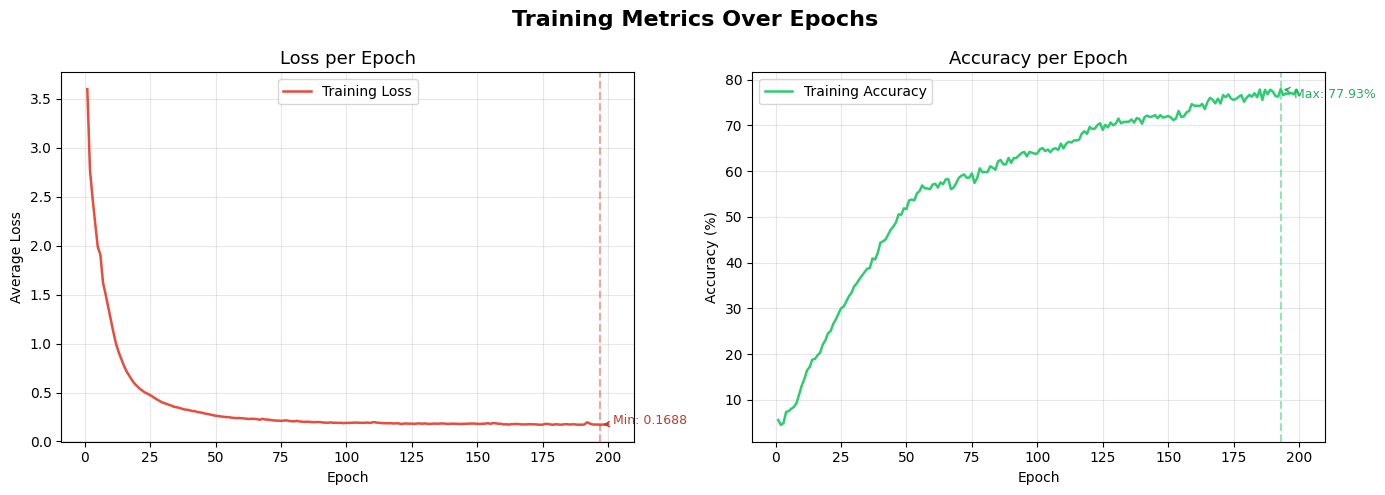

Best loss: 0.1688 at epoch 197
Best accuracy: 77.93% at epoch 193


In [46]:
import matplotlib.pyplot as plt

epochs_range = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Metrics Over Epochs', fontsize=16, fontweight='bold')

# ── Loss curve ──
axes[0].plot(epochs_range, train_losses, color='#e74c3c', linewidth=1.8, label='Training Loss')
axes[0].set_title('Loss per Epoch', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Average Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Mark minimum loss
min_loss_epoch = train_losses.index(min(train_losses)) + 1
axes[0].axvline(x=min_loss_epoch, color='#e74c3c', linestyle='--', alpha=0.5,
                label=f'Min loss @ epoch {min_loss_epoch}')
axes[0].annotate(f'Min: {min(train_losses):.4f}',
                 xy=(min_loss_epoch, min(train_losses)),
                 xytext=(min_loss_epoch + 5, min(train_losses) + 0.01),
                 arrowprops=dict(arrowstyle='->', color='#c0392b'),
                 fontsize=9, color='#c0392b')

# ── Accuracy curve ──
axes[1].plot(epochs_range, train_accuracies, color='#2ecc71', linewidth=1.8, label='Training Accuracy')
axes[1].set_title('Accuracy per Epoch', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Mark maximum accuracy
max_acc_epoch = train_accuracies.index(max(train_accuracies)) + 1
axes[1].axvline(x=max_acc_epoch, color='#2ecc71', linestyle='--', alpha=0.5,
                label=f'Max acc @ epoch {max_acc_epoch}')
axes[1].annotate(f'Max: {max(train_accuracies):.2f}%',
                 xy=(max_acc_epoch, max(train_accuracies)),
                 xytext=(max_acc_epoch + 5, max(train_accuracies) - 2),
                 arrowprops=dict(arrowstyle='->', color='#27ae60'),
                 fontsize=9, color='#27ae60')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best loss: {min(train_losses):.4f} at epoch {min_loss_epoch}")
print(f"Best accuracy: {max(train_accuracies):.2f}% at epoch {max_acc_epoch}")


This section is responsible for saving the trained neural network model and associated metadata to a file. This saved checkpoint (`data.pth`) can then be loaded later for inference without needing to retrain the model.

1.  **`model_checkpoint` Dictionary**: A dictionary is created to store all necessary information:
    *   `strategy`: Indicates the method used (e.g., "bow" for Bag-of-Words).
    *   `threshold`: A confidence threshold (0.7) for predictions, used to determine if an intent is sufficiently clear.
    *   `model_state`: The `state_dict()` of the PyTorch model, which contains all the learned weights and biases.
    *   `input_size`, `hidden_size`, `output_size`: The architectural parameters of the network.
    *   `all_words`: The vocabulary list used during training.
    *   `tags`: The list of intent tags.
2.  **`torch.save()`**: The entire `model_checkpoint` dictionary is saved to a file named `data.pth` using PyTorch's serialization function.
3.  **Confirmation and Summary**: Prints messages confirming the successful saving of the model and details the contents of the saved checkpoint, ensuring that all critical components for future inference are stored.

## Section 6: Evaluate Model Performance

Evaluate the trained model on the training data and calculate accuracy metrics.

This section explains how to load the previously saved model (`data.pth`) and use it to predict the intent of new, unseen user sentences. This is the inference part of the chatbot, allowing it to respond to user queries based on its training.

1.  **Load Checkpoint**: The `torch.load()` function is used to load the saved `data.pth` file. `map_location=torch.device('cpu')` ensures it can be loaded on any device, even if it was trained on a GPU.
2.  **Restore Metadata**: Essential metadata like `all_words`, `tags`, and `threshold` are extracted from the loaded checkpoint.
3.  **Rebuild and Load Model**:
    *   A new `NeuralNet` instance (`model_inf`) is created with the same architecture parameters (`input_size`, `hidden_size`, `output_size`) as the trained model.
    *   `model_inf.load_state_dict(checkpoint['model_state'])` loads the learned weights and biases into the new model.
    *   `model_inf.eval()`: Sets the model to evaluation mode, which is important for inference as it disables dropout and batch normalization layers if present.
4.  **`predict_intent` Function**: This function encapsulates the inference logic:
    *   Takes a `sentence` as input.
    *   `tokenize()`: Tokenizes the input sentence.
    *   `bag_of_words()`: Converts tokens to a Bag-of-Words vector.
    *   Converts the BoW vector to a PyTorch tensor.
    *   `model_inf(x)`: Performs a forward pass to get raw `logits`.
    *   `torch.softmax()`: Converts logits into probabilities.
    *   `torch.max()`: Finds the maximum probability (`conf`) and its corresponding `idx` (predicted intent).
    *   Retrieves the `tag` from the `tags` list.
    *   Prints the predicted intent and its confidence, also indicating if the confidence falls below the defined `threshold`.
5.  **Sample Predictions**: A list of `test_sentences` is defined, and the `predict_intent` function is called for each, demonstrating the model's ability to classify new inputs.

In [47]:
# Evaluate model accuracy on training data
with torch.no_grad():
    correct = 0
    total = 0
    predictions = []

    for i in range(len(X_train)):
        # Get input
        x = torch.from_numpy(X_train[i]).float()

        # Forward pass
        out = model(x)
        _, predicted = torch.max(out.data, 0)

        # Count correct predictions
        total += 1
        correct += (predicted == y_train[i]).item()
        predictions.append(predicted.item())

# Calculate accuracy
accuracy = 100 * correct / total

print(f"Model Evaluation Results:")
print(f"  Total samples: {total}")
print(f"  Correct predictions: {correct}")
print(f"  Model Accuracy on Training Data: {accuracy:.2f}%")

Model Evaluation Results:
  Total samples: 2537
  Correct predictions: 1945
  Model Accuracy on Training Data: 76.67%


This markdown cell serves as a clear heading for the next section, which will contain code to predict the intent of user input using the previously trained and saved model. It reiterates that the `data.pth` file is required for this section to function correctly, emphasizing the dependency on the model saving step.

## Section 6.1: Visualize Confusion Matrix

Visualize the confusion matrix to see how well the model classifies each intent category.

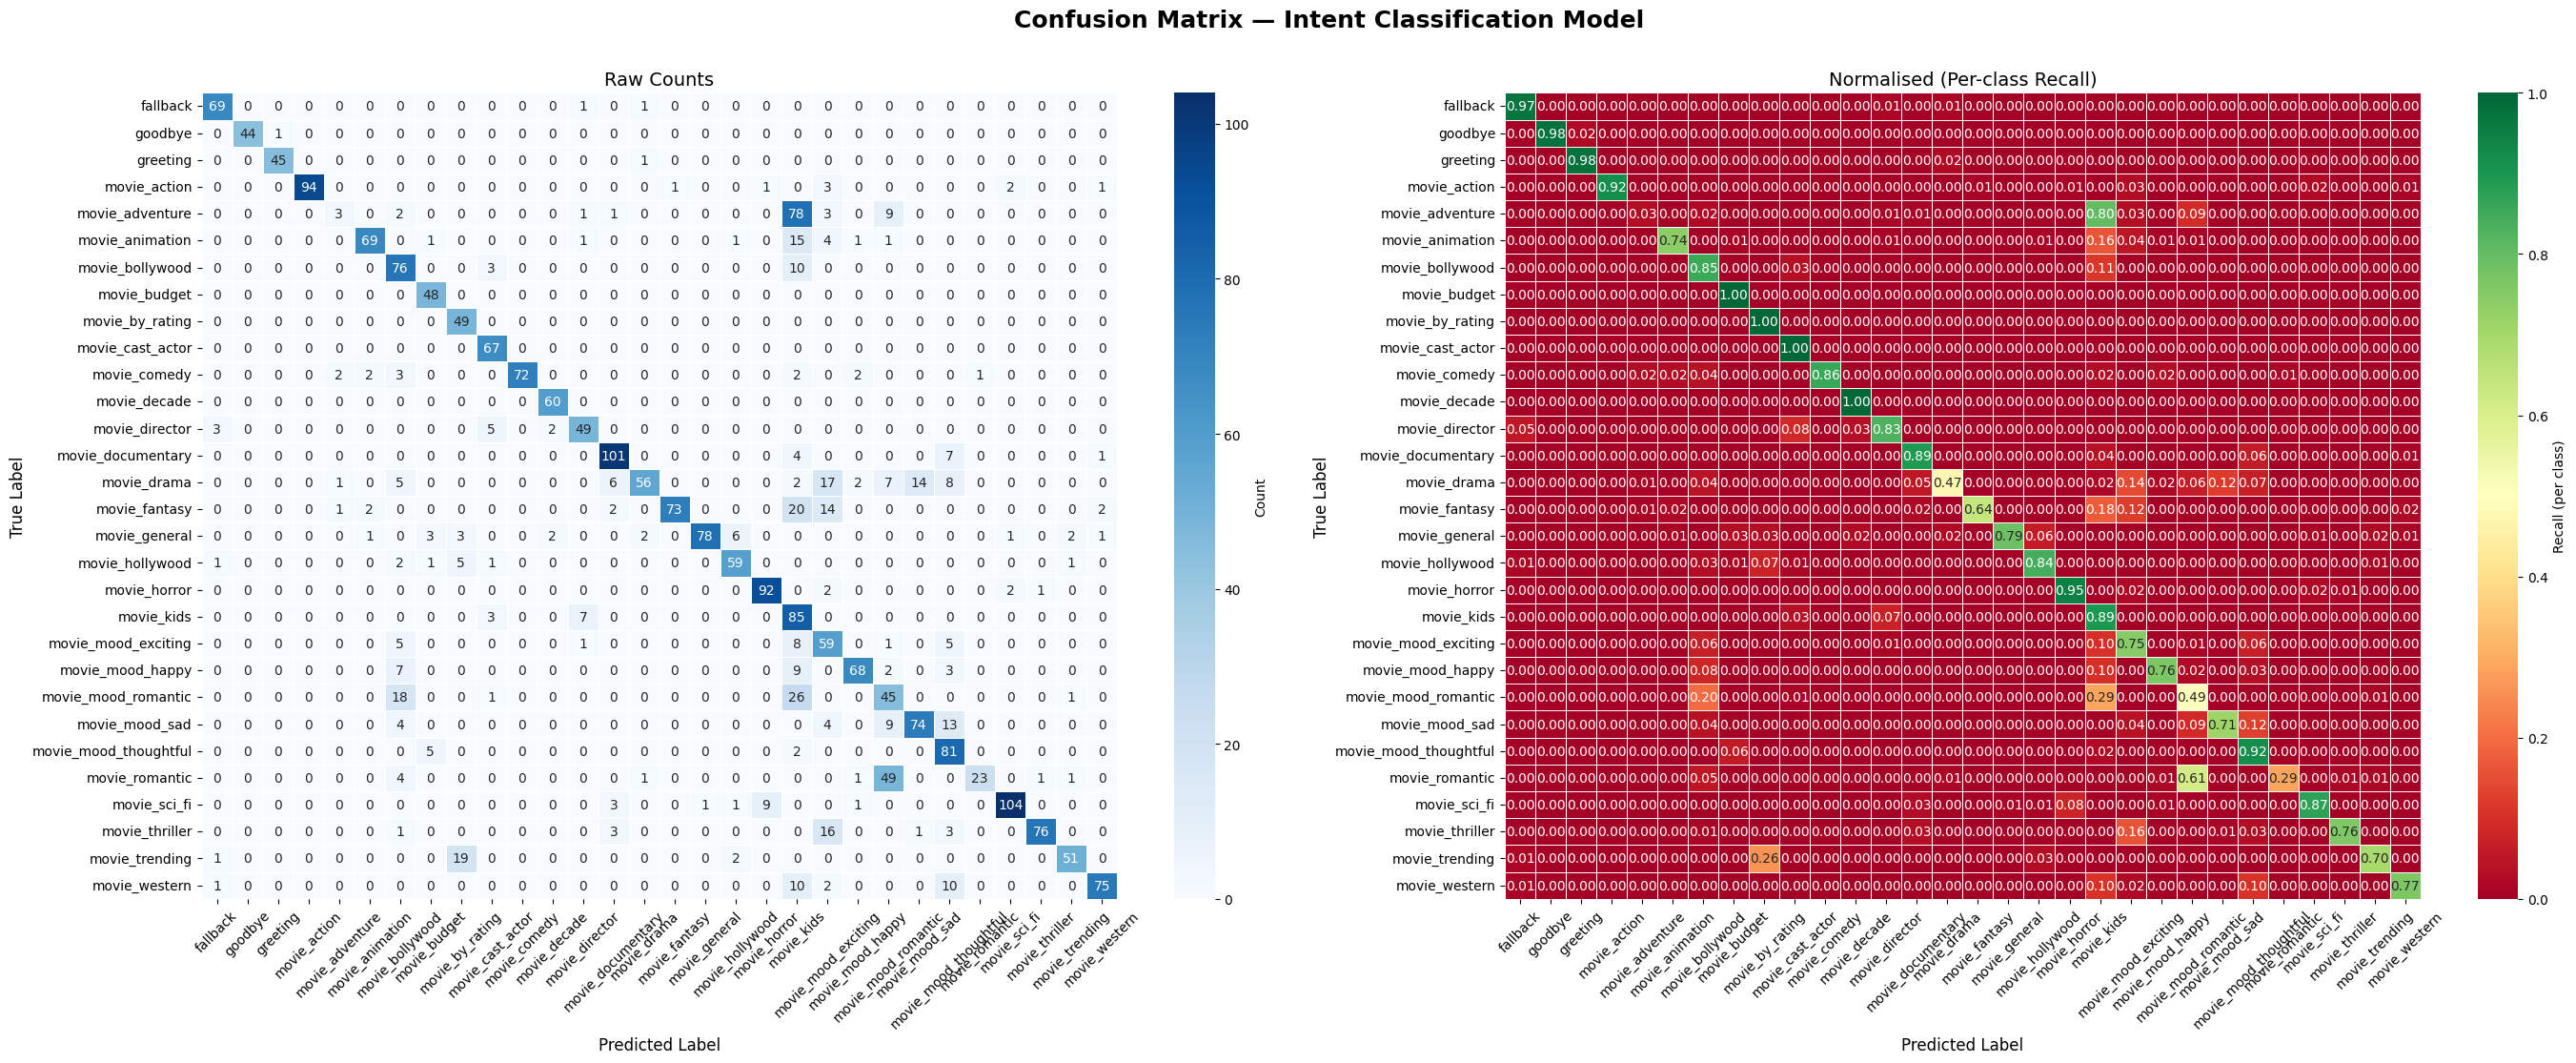


Classification Report:
                       precision    recall  f1-score   support

             fallback       0.92      0.97      0.95        71
              goodbye       1.00      0.98      0.99        45
             greeting       0.98      0.98      0.98        46
         movie_action       1.00      0.92      0.96       102
      movie_adventure       0.43      0.03      0.06        97
      movie_animation       0.93      0.74      0.83        93
      movie_bollywood       0.60      0.85      0.70        89
         movie_budget       0.83      1.00      0.91        48
      movie_by_rating       0.64      1.00      0.78        49
     movie_cast_actor       0.84      1.00      0.91        67
         movie_comedy       1.00      0.86      0.92        84
         movie_decade       0.94      1.00      0.97        60
       movie_director       0.82      0.83      0.82        59
    movie_documentary       0.87      0.89      0.88       113
          movie_drama       0.

In [48]:
# Import necessary libraries for confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Generate predictions on training data
all_predictions = []
all_true_labels = []

with torch.no_grad():
    for i in range(len(X_train)):
        x = torch.from_numpy(X_train[i]).float()
        out = model(x)
        _, predicted = torch.max(out.data, 0)
        all_predictions.append(predicted.item())
        all_true_labels.append(y_train[i])

# Compute confusion matrix
cm = confusion_matrix(all_true_labels, all_predictions)

# Normalize for percentage view
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# ── Plot raw count confusion matrix ──
fig, axes = plt.subplots(1, 2, figsize=(28, 11))
fig.suptitle('Confusion Matrix — Intent Classification Model', fontsize=18, fontweight='bold', y=1.01)

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=tags, yticklabels=tags,
            cbar_kws={'label': 'Count'},
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Raw Counts', fontsize=14)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Normalised (per-class recall)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=tags, yticklabels=tags,
            vmin=0, vmax=1,
            cbar_kws={'label': 'Recall (per class)'},
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Normalised (Per-class Recall)', fontsize=14)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print classification report
print("\nClassification Report:")
print("=" * 60)
print(classification_report(all_true_labels, all_predictions, target_names=tags))


## Section 7: Save Trained Model

Save the trained model and related metadata to disk for later inference.

In [49]:
# Save the trained model and metadata
model_checkpoint = {
    "strategy": "bow",  # Bag-of-Words strategy
    "threshold": 0.7,  # Confidence threshold for predictions
    "model_state": model.state_dict(),
    "input_size": len(X_train[0]),
    "hidden_size": hidden_size,
    "output_size": len(tags),
    "all_words": all_words,
    "tags": tags
}

torch.save(model_checkpoint, "data.pth")

print("Model saved successfully!")
print(f"\nSaved checkpoint contains:")
print(f"  - Model state dictionary")
print(f"  - Strategy: {model_checkpoint['strategy']}")
print(f"  - Confidence threshold: {model_checkpoint['threshold']}")
print(f"  - Input size: {model_checkpoint['input_size']}")
print(f"  - Hidden size: {model_checkpoint['hidden_size']}")
print(f"  - Output size: {model_checkpoint['output_size']}")
print(f"  - Vocabulary size: {len(model_checkpoint['all_words'])}")
print(f"  - Number of intents: {len(model_checkpoint['tags'])}")

Model saved successfully!

Saved checkpoint contains:
  - Model state dictionary
  - Strategy: bow
  - Confidence threshold: 0.7
  - Input size: 1774
  - Hidden size: 8
  - Output size: 30
  - Vocabulary size: 1774
  - Number of intents: 30


## Section 8: Predict Intent from Saved Model (`data.pth`)

Load the saved checkpoint and run inference on arbitrary user input without retraining. The model file `data.pth` must exist in the working directory (produced by Section 7).

## Section 8: Predict Intent from Saved Model (`data.pth`)

Load the saved checkpoint and run inference on arbitrary user input without retraining. The model file `data.pth` must exist in the working directory (produced by Section 7).

In [50]:
import torch
import json


# ── Load checkpoint ──
checkpoint_path = "data.pth"
checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))

# Restore vocabulary and labels
all_words = checkpoint['all_words']
tags      = checkpoint['tags']
threshold = checkpoint.get('threshold', 0.7)

# Rebuild model and load saved weights
model_inf = NeuralNet(
    input_size  = checkpoint['input_size'],
    hidden_size = checkpoint['hidden_size'],
    num_classes = checkpoint['output_size']
)
model_inf.load_state_dict(checkpoint['model_state'])
model_inf.eval()

print(f"Model loaded from '{checkpoint_path}'")
print(f"  Vocabulary size      : {len(all_words)}")
print(f"  Intent classes       : {len(tags)}")
print(f"  Confidence threshold : {threshold}")
print(f"  Tags: {tags}")


def predict_intent(sentence: str, verbose: bool = True):
    """Return (predicted_tag, confidence) for a given sentence."""
    tokens = tokenize(sentence)
    bow    = bag_of_words(tokens, all_words)
    x      = torch.from_numpy(bow).float()

    with torch.no_grad():
        logits = model_inf(x)
        probs  = torch.softmax(logits, dim=0)
        conf, idx = torch.max(probs, dim=0)

    conf_val = conf.item()
    tag      = tags[idx.item()]

    if verbose:
        print(f"\nInput      : '{sentence}'")
        print(f"Predicted  : {tag}")
        print(f"Confidence : {conf_val:.4f} ({conf_val*100:.2f}%)")
        if conf_val < threshold:
            print(f"  ⚠️  Below threshold ({threshold}) — intent unclear")

    return tag, conf_val


# ── Sample predictions ──
test_sentences = [
    "Hello there!",
    "Suggest me a good horror movie",
    "I want to watch a romantic comedy",
    "Show me some action films",
    "Goodbye, see you later",
    "recommend something funny",
    "xyzzy randomgarbage abc",
]

print("\n" + "="*55)
print("         INFERENCE ON SAMPLE SENTENCES")
print("="*55)
for sent in test_sentences:
    predict_intent(sent)


Model loaded from 'data.pth'
  Vocabulary size      : 1774
  Intent classes       : 30
  Confidence threshold : 0.7
  Tags: ['fallback', 'goodbye', 'greeting', 'movie_action', 'movie_adventure', 'movie_animation', 'movie_bollywood', 'movie_budget', 'movie_by_rating', 'movie_cast_actor', 'movie_comedy', 'movie_decade', 'movie_director', 'movie_documentary', 'movie_drama', 'movie_fantasy', 'movie_general', 'movie_hollywood', 'movie_horror', 'movie_kids', 'movie_mood_exciting', 'movie_mood_happy', 'movie_mood_romantic', 'movie_mood_sad', 'movie_mood_thoughtful', 'movie_romantic', 'movie_sci_fi', 'movie_thriller', 'movie_trending', 'movie_western']

         INFERENCE ON SAMPLE SENTENCES

Input      : 'Hello there!'
Predicted  : greeting
Confidence : 1.0000 (100.00%)

Input      : 'Suggest me a good horror movie'
Predicted  : movie_sci_fi
Confidence : 0.9947 (99.47%)

Input      : 'I want to watch a romantic comedy'
Predicted  : movie_comedy
Confidence : 0.9937 (99.37%)

Input      : 'Show